# Transformer-Based Models - ReMA (RU)


# **Tutorial 1**
### Last update: 2024/11/06
#### Aditya Parikh (aditya.parikh@ru.nl)
-----------------------------------------

In this first practical tutorial about Transformer-based models, we will explore the following questions:

1. Why did Transformers come into existence?
2. Understanding Tokens
3. Why is the self-attention mechanism necessary?

Once we have addressed these foundational concepts, in the following tutorials we will be able to implement a self-attention block, add positional encoding, and perhaps even create a tiny GPT model.


## Question: What are transformer pretrained models made of?

You should try to figure out the amount of data required to create a model like GPT. A good startign point is the following paper: [Language Models are Few-Shot Learners](https://arxiv.org/pdf/2005.14165).

In this tutorial, we are using PyTorch:  https://pytorch.org. In particular,
see the steps below in the code:

In [ ]:
# Start with downloading a training dataset.
!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txthttps://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

--2024-11-07 08:41:34--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt.1’

input.txt.1         100%[===================>]   1.06M  --.-KB/s    in 0.01s   

2024-11-07 08:41:34 (92.4 MB/s) - ‘input.txt.1’ saved [1115394/1115394]



In [ ]:
# Read the data
with open('input.txt', 'r', encoding='utf-8') as f:
    raw_text = f.read()


print(raw_text[:1000])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.



Now once you have text, next step is to create a tokenizer.

## Question: Why a ***tokenizer*** is required?
Task: Create your own character based tokenizer.

*   Make a list of all the unique characters that occurs in this text.
*   Calculate the length of your vocabulary.
*   Play with few phrases, encode and decode the tokens.  




In [ ]:
chars = sorted(list(set(raw_text)))
vocab_size = len(chars)
print("Unique Characters")
print(''.join(chars))
print("Vocab Size: ",vocab_size)

Unique Characters

 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
Vocab Size:  65


Now you need to make a mapping between characters to integers to convert textual data into a numerical representation that can be processed by machine learning algorithms. With this numeric representation we can train the model to perform various tasks, such as classification, sentiment analysis, or language generation.  

In the code below, you need to create an `encode` function that convert a *string* to a *list* of *integer* indices and `decode` function that convert *integer* indices to *strings*.

In [ ]:
def build_vocab(chars):
    string_to_int = {ch: i for i, ch in enumerate(chars)}
    int_to_string = {i: ch for i, ch in enumerate(chars)}
    return string_to_int, int_to_string


string_to_int, int_to_string = build_vocab(chars)

# Make an encoder function: Converts a string to a list of integer indices
def encode(text, string_to_int):
    return [string_to_int[c] for c in text]

# Decoder function: Converts a list of integer indices back to a string
def decode(indices, int_to_string):
    return ''.join(int_to_string[i] for i in indices)


sample_text = "hello how are you doing"
encoded = encode(sample_text, string_to_int)
decoded = decode(encoded, int_to_string)

print(f"Original text: {sample_text}")
print(f"Encoded: {encoded}")
print(f"Decoded: {decoded}")

Original text: hello how are you doing
Encoded: [46, 43, 50, 50, 53, 1, 46, 53, 61, 1, 39, 56, 43, 1, 63, 53, 59, 1, 42, 53, 47, 52, 45]
Decoded: hello how are you doing


Finally, *encode* your entire text and create a `torch.Tensor`

In [ ]:
import torch
encoded_data = torch.tensor(encode(raw_text,string_to_int), dtype=torch.long)

encoded_data.shape

torch.Size([1115394])

In [ ]:
encoded_data[:1000]

tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59,  1, 39, 56, 43,  1, 39, 50, 50,
         1, 56, 43, 57, 53, 50, 60, 43, 42,  1, 56, 39, 58, 46, 43, 56,  1, 58,
        53,  1, 42, 47, 43,  1, 58, 46, 39, 52,  1, 58, 53,  1, 44, 39, 51, 47,
        57, 46, 12,  0,  0, 13, 50, 50, 10,  0, 30, 43, 57, 53, 50, 60, 43, 42,
         8,  1, 56, 43, 57, 53, 50, 60, 43, 42,  8,  0,  0, 18, 47, 56, 57, 58,
         1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 18, 47, 56, 57, 58,  6,  1, 63,
        53, 59,  1, 49, 52, 53, 61,  1, 15, 39, 47, 59, 57,  1, 25, 39, 56, 41,
        47, 59, 57,  1, 47, 57,  1, 41, 

Once you know how the tokenizer works: Please check out some popular tokenizers. For example: The `tiktoken` library is a tokenizer specifically designed to work with OpenAI models like GPT-3 and GPT-4.

Do you know others?

How do you choose the best tokenizer for your task?

In [ ]:
%%capture
!pip install tiktoken

In [ ]:
import tiktoken

# Load the tokenizer for a specific base encoding
enc = tiktoken.get_encoding("cl100k_base")

# Visualise how the GPT-4 encoder encodes text
encoded_text = enc.encode("hello how are you doing aaaaaaaaaa")
print("Encoded:", encoded_text)

decoded_text = enc.decode(encoded_text)
print("Decoded:", decoded_text)

# Total number of tokens in encoder
print("total_tokens", enc.n_vocab)

Encoded: [15339, 1268, 527, 499, 3815, 264, 70540, 64]
Decoded: hello how are you doing aaaaaaaaaa
total_tokens 100277


## Context Window

A c*ontext window* refers to the amount of text data a language model can consider at one time when generating responses. It includes all the tokens (words or pieces of words) from the input text that the model looks at to gather context before replying. The size of this window directly influences the model’s understanding and response accuracy.

What is the context window of current GPT models? Please refer to [this blog](https://swimm.io/learn/large-language-models/llm-context-windows-basics-examples-and-prompting-best-practices#:~:text=A%20context%20window%20refers%20to,to%20gather%20context%20before%20replying.).  

Understanding the context window is very important to understand use of attention mechanism.

In [ ]:
# If we consider context window = 8
context_window = 8

In [ ]:
x = encoded_data[:context_window]
y = encoded_data[1:context_window+1]
for t in range(context_window):
    context = x[:t+1]
    output = y[t]
    print(f"when input is {context} the output: {output}")

when input is tensor([18]) the output: 47
when input is tensor([18, 47]) the output: 56
when input is tensor([18, 47, 56]) the output: 57
when input is tensor([18, 47, 56, 57]) the output: 58
when input is tensor([18, 47, 56, 57, 58]) the output: 1
when input is tensor([18, 47, 56, 57, 58,  1]) the output: 15
when input is tensor([18, 47, 56, 57, 58,  1, 15]) the output: 47
when input is tensor([18, 47, 56, 57, 58,  1, 15, 47]) the output: 58


But in general, the training data are not like this.

In [ ]:
torch.manual_seed(42)
batch_size = 4     # how many independent sequences will we process in parallel?
context_window = 8 # what is the maximum context length for predictions?

def get_batch(split):
    # generate a small batch of data of inputs x and outputs y
    data = encoded_data
    ix = torch.randint(len(data) - context_window, (batch_size,))
    x = torch.stack([data[i:i+context_window] for i in ix])
    y = torch.stack([data[i+1:i+context_window+1] for i in ix])
    return x, y

xb, yb = get_batch('train')
print('inputs:')
print(xb.shape)
print(xb)
print('outputs:')
print(yb.shape)
print(yb)

inputs:
torch.Size([4, 8])
tensor([[42,  1, 58, 46, 59, 57,  1, 21],
        [54, 56, 47, 43, 57, 58, 11,  0],
        [49, 47, 52, 45, 12,  1, 58, 46],
        [58, 46, 53, 59, 58,  1, 56, 43]])
outputs:
torch.Size([4, 8])
tensor([[ 1, 58, 46, 59, 57,  1, 21,  1],
        [56, 47, 43, 57, 58, 11,  0, 37],
        [47, 52, 45, 12,  1, 58, 46, 53],
        [46, 53, 59, 58,  1, 56, 43, 42]])


The last concept of this tutorial is the *attention mechanism*.
From the example above, here are the important aspects for input and output tokens:

*   All tokens within the context window should be able to communicate with previous tokens. You need to consider the weights of all the previous tokens in order to generate the next token.
*   Tokens in the context window should not be able to communicate with subsequent tokens.

In the next tutorial, we will consider the aspects above as we implement the self-attention mechanism and other important features of transformer models.


But before that consider reading these:

[The Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/)

[Transformers, what can they do?](https://huggingface.co/learn/nlp-course/en/chapter1/3?fw=pt)

Also try to play with different transformers based models on Hugging Face and the code of this tutorial 🤗

See you in the next one :-)



# **Tutorial 2**
### Last update: 2024/11/21
#### Aditya Parikh (aditya.parikh@ru.nl)
-----------------------------------------

In this tutorial we are discussing the self-attention mechanism. Once we know how it works, we will continue with our tiny Shakespeare example to build a tiny GPT model.

Below there is a toy example illustrating how you can do a matrix multiplication and it can be used for "weighted aggregation":

In [ ]:
import torch
import torch.nn as nn
from torch.nn import functional as F

In [ ]:
torch.manual_seed(1337)
B,T,C = 4,8,2 # batch, time, channels
x = torch.randn(B,T,C)
print(x.shape)

torch.Size([4, 8, 2])


The concept of this tutorial is the *attention mechanism*.
Following the example above, you can see important aspects for the input and output tokens:

*   All tokens within the context window should be able to communicate with previous tokens. You need to consider the weights of all the previous tokens in order to generate the next token.
*   Tokens in the context window should not be able to communicate with subsequent tokens.


Can you imagine a most intuative way to communicate with previous tokens?

In [ ]:
a_initial = torch.ones(3, 3)
print(a_initial)
print("####")
a = torch.tril(a_initial)
print(a)
print("####")
a_final = a/torch.sum(a, 1, keepdim=True)
print(a_final)

tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])
####
tensor([[1., 0., 0.],
        [1., 1., 0.],
        [1., 1., 1.]])
####
tensor([[1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.3333, 0.3333, 0.3333]])


In [ ]:
torch.manual_seed(42)
b = torch.randint(0,10,(3,2)).float()
b

tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])

In [ ]:
c = a_final @ b
c

tensor([[2.0000, 7.0000],
        [4.0000, 5.5000],
        [4.6667, 5.3333]])

Now we will try to do similar task with our (B,T,C) matrix.

In [ ]:
tril = torch.tril(torch.ones(T, T))
tril

tensor([[1., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1.]])

In [ ]:
wei = torch.zeros((T,T))
wei

tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]])

In [ ]:
wei = wei.masked_fill(tril == 0, float('-inf'))
wei

tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0., 0., 0., 0.]])

In [ ]:
wei = F.softmax(wei, dim=-1)
wei

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000, 0.0000],
        [0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000],
        [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0000],
        [0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250]])

In [ ]:
xbow = wei @ x # (T,T)@(B,T,C) --> (B,T,T)@(B,T,C) --> (B,T,C)

In [ ]:
xbow[0]

tensor([[ 0.1808, -0.0700],
        [-0.0894, -0.4926],
        [ 0.1490, -0.3199],
        [ 0.3504, -0.2238],
        [ 0.3525,  0.0545],
        [ 0.0688, -0.0396],
        [ 0.0927, -0.0682],
        [-0.0341,  0.1332]])

In [ ]:
x[0]

tensor([[ 0.1808, -0.0700],
        [-0.3596, -0.9152],
        [ 0.6258,  0.0255],
        [ 0.9545,  0.0643],
        [ 0.3612,  1.1679],
        [-1.3499, -0.5102],
        [ 0.2360, -0.2398],
        [-0.9211,  1.5433]])

There is an issue with the above method, can you think about it?

We are taking here simple average and normalized values of weights. That means each token have an equal amount of weight. But in general scenario, it does not work like that.


For example:

`Amsterdam is a major city in the Netherlands`  

In this example: On which token/tokens will you give more weight? Or in other words, which word relates the most with `the Netherlands`?

So, we need to gather this information from previous tokens in a data dependent way. That is the problem self-attention is solving.

## Self-attention

A simple explaination:

Every single token at each position will emit two vectors.
1. Query (*what I am looking for?*)
2. Key   (*what do I contain?*)

We find the relations between different words by doing `dot product` with keys and queries. A `query` will do a `dot product` with all previous token's `key`. This `dot product` will become your new weight. If a specific tokens key and query will align, they will have a higher weight than all other token.

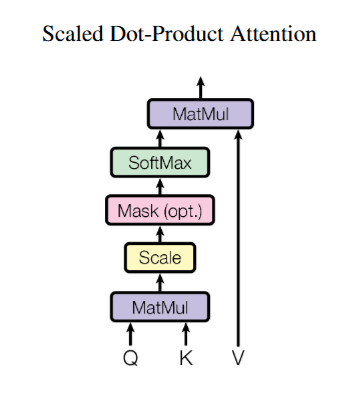



In [ ]:
torch.manual_seed(1337)
B,T,C = 4,8,32 # batch, time, channels
x = torch.randn(B,T,C)

# let's see a single Head perform self-attention
head_size = 16

key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
value = nn.Linear(C, head_size, bias=False)

k = key(x)   # (B, T, 16)
q = query(x) # (B, T, 16)
v = value(x)

wei =  q @ k.transpose(-2, -1) * head_size**-0.5
# (B, T, 16) @ (B, 16, T) ---> (B, T, T)


In [ ]:
#check the new weight
print(wei.shape)
print(wei[0])

torch.Size([4, 8, 8])
tensor([[-0.4407, -0.3253,  0.1413,  0.5404, -0.2668,  0.4908,  0.2691, -0.1132],
        [-0.8334, -0.4139,  0.0260,  0.8446, -0.5456,  0.2604, -0.0139,  0.0732],
        [-0.2557, -0.3152,  0.0191, -0.0953, -0.2461, -0.3576,  0.0187, -0.2387],
        [ 0.1959, -0.2004, -0.0842, -0.2124, -0.1401, -0.2925, -0.3232, -0.2565],
        [-0.3142,  0.0047, -0.1970, -0.3301,  0.5091,  0.2160,  0.0930,  0.2314],
        [-0.0782,  0.6038, -0.0276, -0.2483,  0.8362, -0.6307,  0.3547,  0.3049],
        [ 0.2719,  0.4913, -0.0655, -0.0789,  0.1523,  0.3154, -0.1371,  0.2012],
        [-0.4511, -0.1031, -0.2077,  0.1475, -0.1997, -0.1464,  0.1608,  0.1576]],
       grad_fn=<SelectBackward0>)


In [ ]:
wei = F.softmax(wei, dim=-1)
print(wei[0])

tensor([[0.0728, 0.0818, 0.1304, 0.1943, 0.0867, 0.1849, 0.1481, 0.1011],
        [0.0518, 0.0788, 0.1224, 0.2774, 0.0691, 0.1547, 0.1176, 0.1283],
        [0.1152, 0.1086, 0.1517, 0.1353, 0.1163, 0.1041, 0.1516, 0.1172],
        [0.1769, 0.1190, 0.1337, 0.1176, 0.1264, 0.1085, 0.1053, 0.1125],
        [0.0855, 0.1177, 0.0962, 0.0842, 0.1949, 0.1454, 0.1285, 0.1476],
        [0.0913, 0.1806, 0.0960, 0.0770, 0.2278, 0.0525, 0.1408, 0.1339],
        [0.1391, 0.1732, 0.0992, 0.0979, 0.1234, 0.1452, 0.0924, 0.1296],
        [0.0845, 0.1197, 0.1078, 0.1537, 0.1086, 0.1146, 0.1558, 0.1553]],
       grad_fn=<SelectBackward0>)


In [ ]:
tril = torch.tril(torch.ones(T, T))
wei = wei.masked_fill(tril == 0, float('-inf')) #If we remove this line, all the tokens will connect to each other (like in BERT). If we keep it, only with the previous ones (ChatGPT)
print(wei)

tensor([[[0.0728,   -inf,   -inf,   -inf,   -inf,   -inf,   -inf,   -inf],
         [0.0518, 0.0788,   -inf,   -inf,   -inf,   -inf,   -inf,   -inf],
         [0.1152, 0.1086, 0.1517,   -inf,   -inf,   -inf,   -inf,   -inf],
         [0.1769, 0.1190, 0.1337, 0.1176,   -inf,   -inf,   -inf,   -inf],
         [0.0855, 0.1177, 0.0962, 0.0842, 0.1949,   -inf,   -inf,   -inf],
         [0.0913, 0.1806, 0.0960, 0.0770, 0.2278, 0.0525,   -inf,   -inf],
         [0.1391, 0.1732, 0.0992, 0.0979, 0.1234, 0.1452, 0.0924,   -inf],
         [0.0845, 0.1197, 0.1078, 0.1537, 0.1086, 0.1146, 0.1558, 0.1553]],

        [[0.1031,   -inf,   -inf,   -inf,   -inf,   -inf,   -inf,   -inf],
         [0.0522, 0.0778,   -inf,   -inf,   -inf,   -inf,   -inf,   -inf],
         [0.1176, 0.0794, 0.1525,   -inf,   -inf,   -inf,   -inf,   -inf],
         [0.1838, 0.1254, 0.1764, 0.1231,   -inf,   -inf,   -inf,   -inf],
         [0.0621, 0.0997, 0.0898, 0.2025, 0.1326,   -inf,   -inf,   -inf],
         [0.0889, 0.095

In [ ]:
wei = F.softmax(wei, dim=-1)
wei

tensor([[[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.4933, 0.5067, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.3300, 0.3278, 0.3422, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.2602, 0.2455, 0.2491, 0.2452, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.1939, 0.2002, 0.1960, 0.1936, 0.2163, 0.0000, 0.0000, 0.0000],
         [0.1615, 0.1766, 0.1623, 0.1592, 0.1851, 0.1554, 0.0000, 0.0000],
         [0.1449, 0.1499, 0.1393, 0.1391, 0.1427, 0.1458, 0.1383, 0.0000],
         [0.1200, 0.1243, 0.1228, 0.1286, 0.1229, 0.1237, 0.1289, 0.1288]],

        [[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.4936, 0.5064, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.3336, 0.3210, 0.3454, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.2579, 0.2433, 0.2560, 0.2427, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.1890, 0.1963, 0.1943, 0.2175, 0.2028, 0.0000, 0.0000, 0.0000],
         [0.1652, 0.166

In [ ]:
output = wei @ v

In [ ]:
output.shape #16 dimensions based on attention weight

torch.Size([4, 8, 16])

In [ ]:
output[0]

tensor([[-0.1571,  0.8801,  0.1615, -0.7824, -0.1429,  0.7468,  0.1007, -0.5239,
         -0.8873,  0.1907,  0.1762, -0.5943, -0.4812, -0.4860,  0.2862,  0.5710],
        [ 0.3442,  0.0214, -0.0846, -0.1228, -0.1339,  0.1201, -0.2182, -0.2743,
         -0.3833,  0.5131,  0.4990, -0.3069,  0.0046,  0.0127,  0.0714,  0.9923],
        [ 0.4274, -0.0621, -0.2638,  0.0512,  0.0257, -0.0479, -0.0952, -0.1089,
         -0.3021,  0.0319,  0.3837, -0.0458, -0.1484, -0.0234, -0.0483,  1.1230],
        [ 0.4770, -0.2072, -0.3406,  0.1319,  0.2351, -0.2514, -0.0542, -0.0442,
         -0.1045,  0.0922,  0.1187,  0.0767,  0.0046,  0.1387,  0.1845,  0.8568],
        [ 0.4165,  0.0470, -0.0895,  0.1678,  0.2512,  0.0175,  0.1178,  0.0685,
         -0.2321, -0.2348, -0.0101, -0.0133, -0.2431,  0.1400,  0.1027,  0.7888],
        [ 0.2153,  0.0470, -0.1237,  0.2764,  0.2676,  0.0432,  0.0252, -0.0345,
         -0.1199, -0.0926,  0.0069,  0.1324, -0.1342,  0.1393,  0.2460,  0.6367],
        [ 0.1034,  0.0

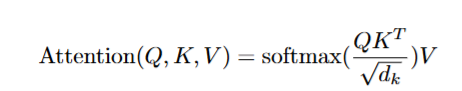

**Question**:
* Why the *attention mechanism* is called self-attention?

In an "encoder" attention block just delete the single line that does masking with tril, allowing all tokens to communicate. This block here is called a "decoder" attention block because it has triangular masking, and is usually used in autoregressive settings, like language modeling.

**Task 1**: Write down the code for encoder attention and decoder attention. Can you tell me what really the difference between both? (Hint: above statement)


**Task 2**: Now you already know single headed attention, can you tell what does it mean with multi-headed attention? May be code it.







In the next tutorial, we will gather all the code to create a GPT from the first 2 tutorials. We will try to create a transformer model that emits shakespeare based on given sequence.

I would recommand you to go through paper "[*Attention is all you need*](https://arxiv.org/pdf/1706.03762)" and read the topics we code out.   